In [9]:
# =====================================
# IMPORT THƯ VIỆN
# =====================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


# =====================================
# ĐỌC FILE
# =====================================

df = pd.read_csv('processed_dulieuxettuyendaihoc.csv')


# =====================================
# SẮP XẾP DỮ LIỆU
# =====================================

print("\nDH1 tăng dần")
print(df.sort_values(by='DH1'))


print("\nDH2 tăng dần theo GT")
print(df.sort_values(by=['GT', 'DH2']))


# =====================================
# HÀM Q1 Q2 Q3
# =====================================

Q1 = lambda x: x.quantile(0.25)
Q2 = lambda x: x.quantile(0.50)
Q3 = lambda x: x.quantile(0.75)


# =====================================
# PIVOT TABLE THEO KT
# =====================================

pivot1 = pd.pivot_table(
    df,
    values='DH1',
    index='KT',
    aggfunc=[
        'count',
        'sum',
        'mean',
        'median',
        'min',
        'max',
        'std',
        Q1,
        Q2,
        Q3
    ]
)

print(pivot1)


# =====================================
# PIVOT TABLE THEO KT VÀ KV
# =====================================

pivot2 = pd.pivot_table(
    df,
    values='DH1',
    index=['KT', 'KV'],
    aggfunc=[
        'count',
        'sum',
        'mean',
        'median',
        'min',
        'max',
        'std',
        Q1,
        Q2,
        Q3
    ]
)

print(pivot2)


# =====================================
# PIVOT TABLE THEO KT KV DT
# =====================================

pivot3 = pd.pivot_table(
    df,
    values='DH1',
    index=['KT', 'KV', 'DT'],
    aggfunc=[
        'count',
        'sum',
        'mean',
        'median',
        'min',
        'max',
        'std',
        Q1,
        Q2,
        Q3
    ]
)

print(pivot3)




DH1 tăng dần
    STT   T1   L1   H1   S1   V1   X1   D1   N1   T2  ...  TBM1  TBM2  TBM3  \
53   54  4.9  5.9  6.2  5.6  5.9  5.0  7.0  5.6  6.1  ...  5.69  6.26  6.02   
43   44  6.6  7.2  5.9  6.9  7.6  8.1  7.3  6.7  6.3  ...  7.05  6.61  6.77   
5     6  9.3  7.6  7.9  8.6  7.0  7.3  7.7  7.9  9.6  ...  7.96  8.54  7.38   
72   73  5.5  6.6  7.2  7.6  5.5  6.7  6.7  5.2  6.0  ...  6.20  5.88  6.22   
83   84  5.9  5.7  7.1  6.7  6.5  8.0  8.1  4.3  7.4  ...  6.47  7.11  7.47   
..  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...   ...   ...   ...   
6     7  2.8  3.9  5.5  6.9  5.0  7.3  4.6  5.2  4.4  ...  4.90  5.60  6.01   
11   12  7.9  7.0  9.1  8.6  6.1  7.0  5.6  9.0  8.2  ...  7.43  7.72  7.49   
23   24  5.3  6.3  5.7  6.9  5.9  7.5  6.6  5.1  6.4  ...  6.05  6.32  6.71   
24   25  2.4  4.1  3.6  5.5  5.9  5.6  4.9  4.2  3.3  ...  4.45  4.88  5.41   
97   98  8.8  5.5  7.4  7.7  6.2  7.3  8.1  4.5  9.5  ...  7.05  7.84  7.67   

    XL1  XL2  XL3   US_TBM1   US_TBM2

GT
M    52
F    48
Name: count, dtype: int64
GT
M    0.52
F    0.48
Name: proportion, dtype: float64


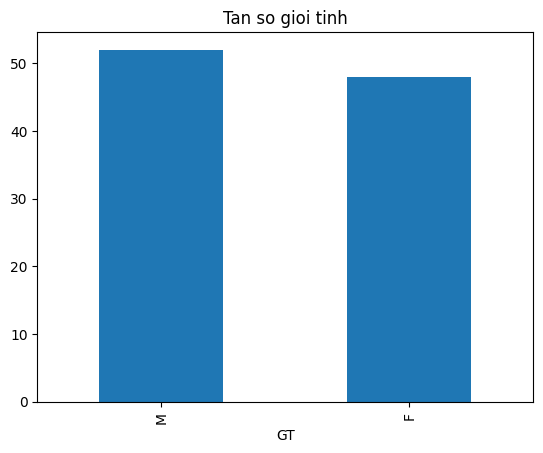

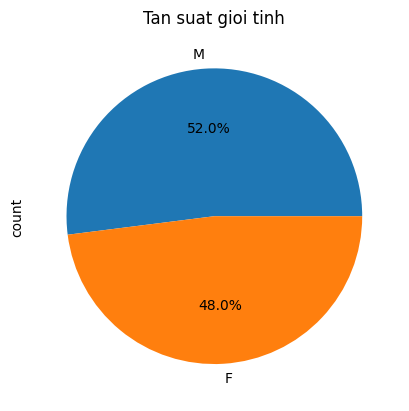

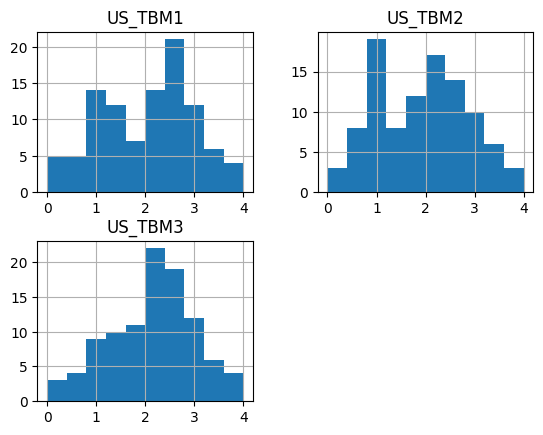

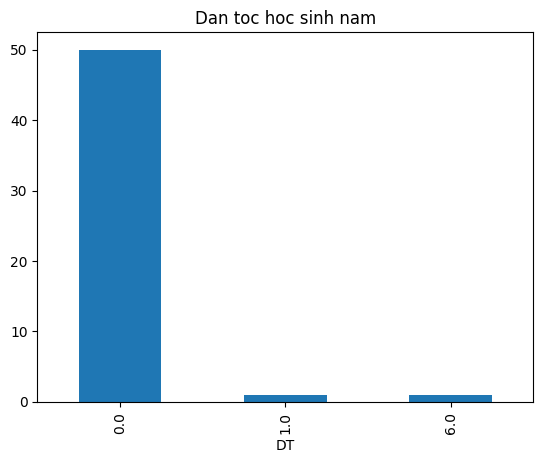

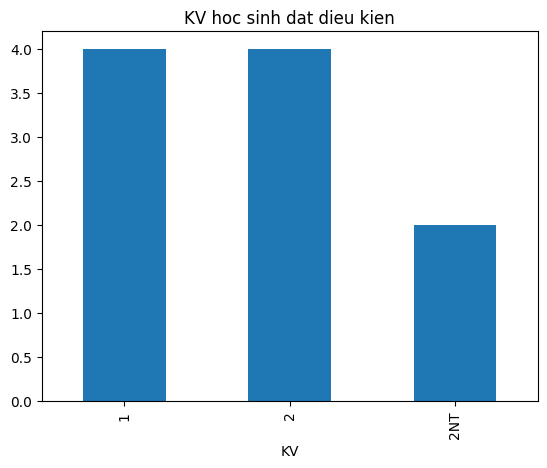

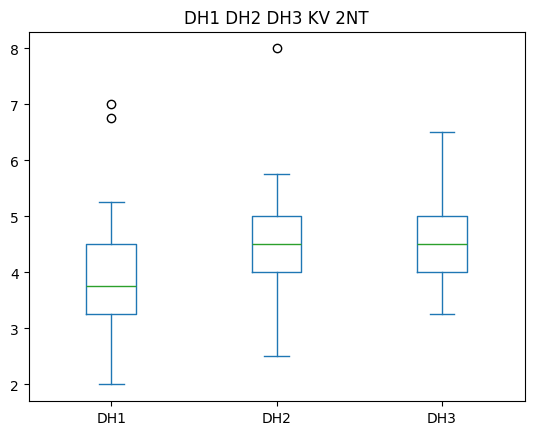

In [10]:
# =====================================
# GT
# =====================================

print(df['GT'].value_counts())

print(df['GT'].value_counts(normalize=True))


# =====================================
# BIỂU ĐỒ CỘT
# =====================================

df['GT'].value_counts().plot(kind='bar')

plt.title('Tan so gioi tinh')

plt.show()


# =====================================
# BIỂU ĐỒ TRÒN
# =====================================

df['GT'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Tan suat gioi tinh')

plt.show()


# =====================================
# US_TBM
# =====================================

df[['US_TBM1', 'US_TBM2', 'US_TBM3']].hist()

plt.show()


# =====================================
# DT HỌC SINH NAM
# =====================================

nam = df[df['GT'] == 'M']

if len(nam) > 0:

    nam['DT'].value_counts().plot(kind='bar')

    plt.title('Dan toc hoc sinh nam')

    plt.show()


# =====================================
# KV HỌC SINH ĐỦ ĐIỀU KIỆN
# =====================================

loc = df[
    (df['DH1'] >= 5) &
    (df['DH2'] >= 4) &
    (df['DH3'] >= 4)
]

if len(loc) > 0:

    loc['KV'].value_counts().plot(kind='bar')

    plt.title('KV hoc sinh dat dieu kien')

    plt.show()


# =====================================
# KV 2NT
# =====================================

loc2 = df[df['KV'] == '2NT']

if len(loc2) > 0:

    loc2[['DH1', 'DH2', 'DH3']].plot.box()

    plt.title('DH1 DH2 DH3 KV 2NT')

    plt.show()

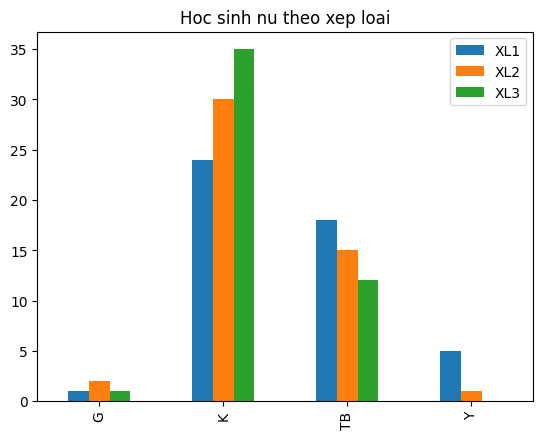

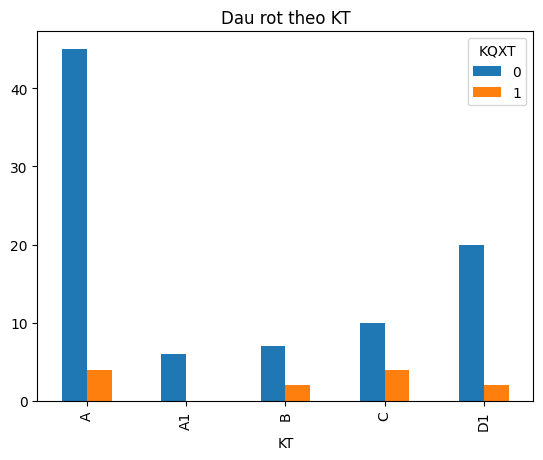

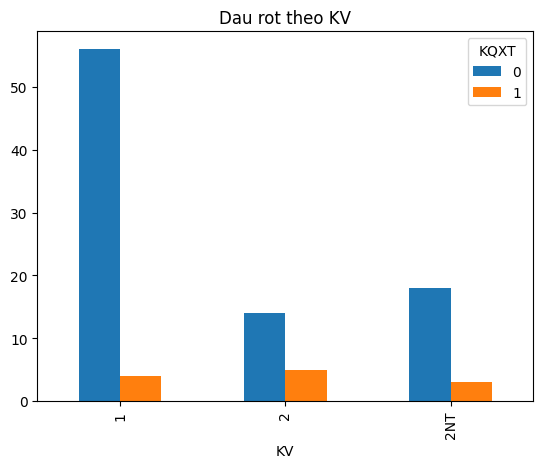

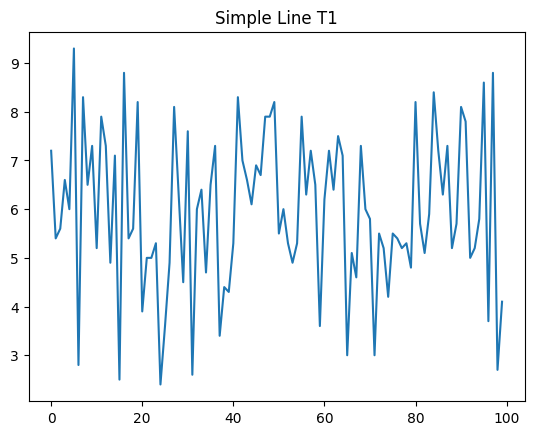

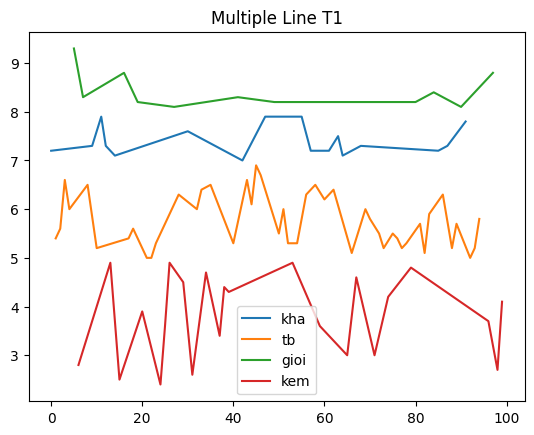

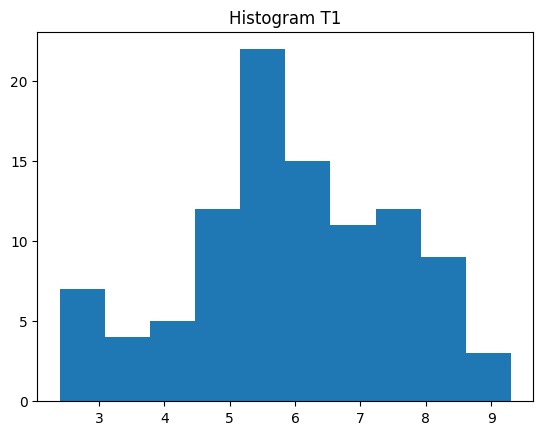

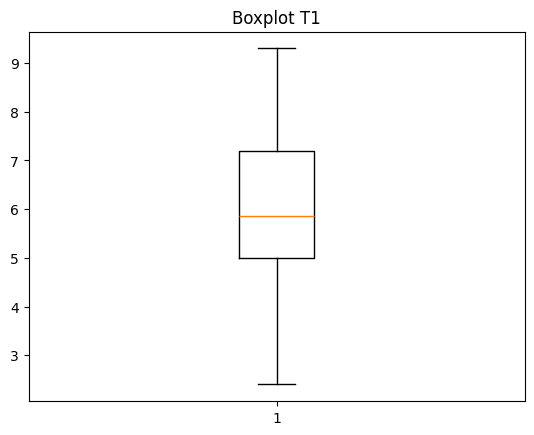

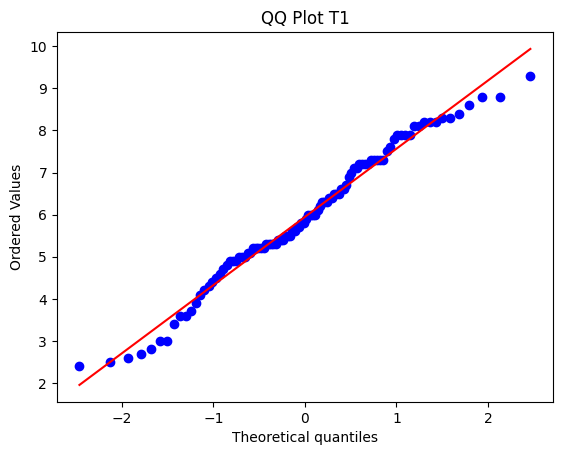

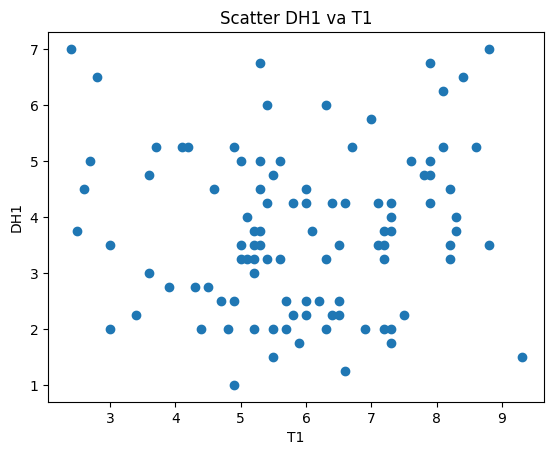

          DH1       DH2       DH3
DH1  1.000000  0.035154  0.018731
DH2  0.035154  1.000000 -0.091523
DH3  0.018731 -0.091523  1.000000


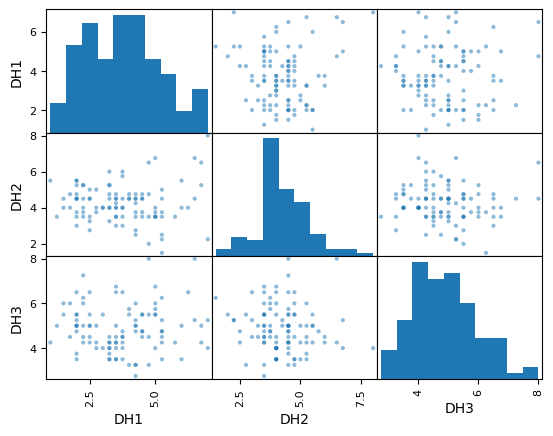

In [11]:
# =====================================
# HỌC SINH NỮ THEO XẾP LOẠI
# =====================================

nu = df[df['GT'] == 'F']

if len(nu) > 0:

    bang = pd.DataFrame({
        'XL1': nu['XL1'].value_counts(),
        'XL2': nu['XL2'].value_counts(),
        'XL3': nu['XL3'].value_counts()
    })

    bang.plot(kind='bar')

    plt.title('Hoc sinh nu theo xep loai')

    plt.show()


# =====================================
# ĐẬU RỚT THEO KT
# =====================================

pd.crosstab(
    df['KT'],
    df['KQXT']
).plot(kind='bar')

plt.title('Dau rot theo KT')

plt.show()


# =====================================
# ĐẬU RỚT THEO KV
# =====================================

pd.crosstab(
    df['KV'],
    df['KQXT']
).plot(kind='bar')

plt.title('Dau rot theo KV')

plt.show()


# =====================================
# SIMPLE LINE
# =====================================

plt.plot(df['T1'])

plt.title('Simple Line T1')

plt.show()


# =====================================
# PHÂN LỚP T1
# =====================================

def phanlop(t):

    if t < 5:
        return 'kem'

    elif t < 7:
        return 'tb'

    elif t < 8:
        return 'kha'

    else:
        return 'gioi'


df['phanlopT1'] = df['T1'].apply(phanlop)


# =====================================
# MULTIPLE LINE
# =====================================

for nhom in df['phanlopT1'].unique():

    temp = df[df['phanlopT1'] == nhom]

    plt.plot(
        temp.index,
        temp['T1'],
        label=nhom
    )

plt.legend()

plt.title('Multiple Line T1')

plt.show()


# =====================================
# HISTOGRAM T1
# =====================================

plt.hist(df['T1'])

plt.title('Histogram T1')

plt.show()


# =====================================
# BOXPLOT T1
# =====================================

plt.boxplot(df['T1'])

plt.title('Boxplot T1')

plt.show()


# =====================================
# QQ PLOT
# =====================================

stats.probplot(
    df['T1'],
    dist='norm',
    plot=plt
)

plt.title('QQ Plot T1')

plt.show()


# =====================================
# SCATTER DH1 VÀ T1
# =====================================

plt.scatter(
    df['T1'],
    df['DH1']
)

plt.xlabel('T1')
plt.ylabel('DH1')

plt.title('Scatter DH1 va T1')

plt.show()


# =====================================
# MA TRẬN TƯƠNG QUAN
# =====================================

print(
    df[['DH1', 'DH2', 'DH3']].corr()
)

pd.plotting.scatter_matrix(
    df[['DH1', 'DH2', 'DH3']]
)

plt.show()
